# Input-data global mean timeseries

Global annual mean `tas` for every GCM, scenario, and ensemble member in the input catalog, drawn
as one line per member and one color per scenario
([issue #530](https://github.com/carbonplan/srm-downscaling/issues/530)). Several downstream QA
findings have turned out to originate upstream, in the raw GCM input:
[issue #529](https://github.com/carbonplan/srm-downscaling/issues/529) reports UKESM stepping about
one degree between the end of `historical` and the start of `ssp245`, and bias correction preserves
a defect of that shape all the way to the published product.

A global mean is a severe reduction, but it is the one a whole class of input defects survives:

| Defect | How it appears |
|---|---|
| Run spliced in from a different model configuration | Step at the junction between runs |
| Missing or all-`NaN` period | Gap, or a year that averages over part of the globe |
| Unit or scaling error applied to a whole run | Constant offset, or a change of slope |
| Member drawn from the wrong parent | Member sitting apart from its siblings |
| Truncated first or last year | Spurious spike at either end of the record |

Section 5 adds a step-change regression at each scenario junction, so a discontinuity comes out as
a number rather than an eyeball judgment.

In [1]:
import os
import pathlib

import coiled
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask_array.xarray import register
from matplotlib.lines import Line2D

from srm.config import GROUP_TO_SCENARIO, ClusterConfig
from srm.datasets import catalog
from srm.lineage import resolve_member_lineage

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
# The reduction and the plotting are written against a single variable name, so re-running this
# notebook for pr or rsds is a one-line change. The prose interprets tas.
VARIABLE = "tas"
GCMS = ["CESM2-WACCM", "UKESM", "MIROC-ES2H"]
SPATIAL = ["lat", "lon"]

# ERA5 is the bias-correction target, so it is the reference the historical period should track.
# The store covers 1950-2014 only, and reading it adds roughly 100 GB to the total.
INCLUDE_ERA5 = True

# A year is plotted only if the store holds at least this fraction of a calendar year of days for
# it, and if at least this fraction of the globe by area was non-NaN. Section 3 explains why both
# guards are needed.
MIN_DAY_FRACTION = 0.9
MIN_AREA_COVERAGE = 0.99

# Scenario colors are a validated categorical palette rather than hand-picked ones. Blue, orange,
# aqua and violet clear the all-pairs check on a light surface (worst CVD dE 9.2 under simulated
# protanopia/deuteranopia, worst normal-vision dE 16.3). The explainer-derived set they replace did
# not: it gave esgf_ssp245 and ssp245 the same hex, and its navy sat below the mark lightness band,
# so it collided with the black ERA5 line. Aqua also reads as the cooled scenario against orange.
SURFACE = "#fcfcfb"
SCENARIO_STYLE = {
    "historical": {"color": "#2a78d6", "linestyle": "-"},
    "ssp245": {"color": "#eb6834", "linestyle": "-"},
    # MIROC's ESGF-archive SSP245, covering the years before the GeoMIP baseline. It takes its own
    # hue rather than a dashed SSP245, because the two are compared directly in the MIROC panel.
    "esgf_ssp245": {"color": "#4a3aa7", "linestyle": "--"},
    # Aqua sits at 2.74:1 against the surface, just under the 3:1 target, so the figures carry
    # direct labels and the junction tables repeat the same values as the required relief channel.
    "g6_1p5k": {"color": "#1baf7a", "linestyle": "-"},
}
# ERA5 is a reference rather than a scenario, so it stays a neutral dashed line and does not
# consume a categorical slot.
OBS_STYLE = {"color": "#0b0b0b", "linestyle": (0, (5, 2))}
# Reserved status colors, kept distinct from the scenario slots so a flag never impersonates a
# series. They are always paired with a text label, never carrying meaning by color alone.
STATUS_CRITICAL, STATUS_NEUTRAL, INK = "#d03b3b", "#8a8a86", "#52514e"
GROUPS = list(SCENARIO_STYLE)

# The reduced series is a few thousand floats, so we cache it outside the repository and skip the
# expensive read on a rerun. Set to None to always recompute.
CACHE_PATH = pathlib.Path.home() / ".cache" / "srm" / f"global-annual-mean-{VARIABLE}.csv"

## 1. Compute

The reduction returns a few thousand floats, so the entire cost is the read: about 360 GB from S3
in `us-west-2`, being the 264 GB of GCM stores inventoried in section 2 plus roughly 100 GB of
ERA5. Cluster settings follow `srm.config.ClusterConfig`.

- `register()` activates frisky's dask array backend for xarray. It must run **before any store is
  opened**, or a later compute raises `Mixing chunked array types`.
- `hijack()` wraps the client so progress stays visible through a read this long.
- Nothing is persisted. Under frisky a `persist` gathers the result to the client, which overflows
  the websocket proxy buffer at this size, so every intermediate stays lazy.

In [2]:
# Roughly 360 GB of reads, an order of magnitude less than the plausible-value check, so a smaller
# pool suffices. The reduction is a per-timestep sum over lat/lon, so intermediates stay tiny and
# the run is read-bound rather than memory-bound.
#
# Use a FIXED pool, not an adaptive one. Each group reduces in one long pass, so a worker that
# vanishes mid-run discards reduction partials that frisky surfaces as an unrecoverable "missing
# dependencies" invariant violation rather than recomputing. A fixed worker count removes adaptive
# downscaling, which is one of the two ways a worker vanishes; uncomment spot_policy="on-demand"
# to remove the other. This run kept the ClusterConfig default, spot_with_fallback, and lost no
# workers.
cfg = ClusterConfig(
    n_workers=20,
    worker_vm_types=["r8g.4xlarge"],
    scheduler_vm_types=["r8g.xlarge"],
    # spot_policy="on-demand",
)
cluster = coiled.Cluster(
    name="srm-qa-input-global-mean",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
)
client = hijack(cluster.get_client())
client

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/srm/srm-0.11.1.post1   │
│                    │ 3+g08b7ea945.d20260728-py3-none-any.whl                 │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

<frisky.Client: scheduler="wss://cluster-lrpwz.dask.host/E2cvsgfW6t4uI03c/frisky-comm?__frisky_dial_host=44.234.47.102" id="client-0">

## 2. The input store layout

One icechunk store per GCM under `s3://carbonplan-srm/input/processed/`, in zarr groups keyed by
scenario. Input and output stores nest ensemble members differently, which matters when adapting
code from [Output integrity checks](./output-integrity-checks.ipynb):

| | Input stores | Output stores |
|---|---|---|
| Layout | `{scenario}` group, `ensemble_member` **dimension** | `{scenario}/{variable}/{member}` **groups** |
| Select a member | `dt["ssp245"].tas.sel(ensemble_member="003")` | `tree["ssp245/tas/003"]` |

The inventory below reads coordinates only. Its `read_gb` column is what section 3 pulls through
the cluster, before the ERA5 read that `INCLUDE_ERA5` adds on top.

In [3]:
trees = {gcm: catalog.get(gcm).to_xarray() for gcm in GCMS}


def inventory_rows(gcm: str, tree: xr.DataTree) -> list[dict]:
    """One row per (gcm, group), from coordinates alone."""
    rows = []
    for group in tree.children:
        ds = tree[group].to_dataset()
        if VARIABLE not in ds.data_vars:
            continue
        time = pd.DatetimeIndex(ds.time.values)
        n_members = ds.sizes.get("ensemble_member", 1)
        cells = ds.sizes["lat"] * ds.sizes["lon"]
        rows.append(
            {
                "gcm": gcm,
                "group": group,
                "scenario": GROUP_TO_SCENARIO.get(group, group),
                "members": n_members,
                "start": time[0].date(),
                "end": time[-1].date(),
                "n_days": len(time),
                "grid": f"{ds.sizes['lat']} x {ds.sizes['lon']}",
                "read_gb": round(n_members * len(time) * cells * 4 / 1e9, 1),
            }
        )
    return rows


inventory = pd.DataFrame(
    [row for gcm, tree in trees.items() for row in inventory_rows(gcm, tree)]
).sort_values(["gcm", "group"], ignore_index=True)
print(f"total to read: {inventory.read_gb.sum():.0f} GB")
inventory

total to read: 264 GB


,gcm,group,scenario,members,start,end,n_days,grid,read_gb
0,CESM2-WACCM,g6_1p5k,G6-1.5K,3,2035-01-01,2084-12-31,18263,192 x 288,12.1
1,CESM2-WACCM,historical,historical,4,1850-01-01,2014-12-31,60265,192 x 288,53.3
2,CESM2-WACCM,ssp245,SSP245,10,2015-01-01,2099-12-31,31046,192 x 288,68.7
3,MIROC-ES2H,esgf_ssp245,esgf-SSP245,3,2015-01-01,2099-12-31,31046,128 x 256,12.2
4,MIROC-ES2H,g6_1p5k,G6-1.5K,10,2035-01-01,2084-12-31,18263,128 x 256,23.9
5,MIROC-ES2H,historical,historical,3,1850-01-01,2014-12-31,60265,128 x 256,23.7
6,MIROC-ES2H,ssp245,SSP245,10,2015-01-01,2084-12-31,25568,128 x 256,33.5
7,UKESM,g6_1p5k,G6-1.5K,3,2035-01-01,2084-12-31,18263,144 x 192,6.1
8,UKESM,historical,historical,3,1850-01-01,2014-12-31,60265,144 x 192,20.0
9,UKESM,ssp245,SSP245,3,2015-01-01,2099-12-31,31046,144 x 192,10.3


## 3. The reduction

Grid cells shrink toward the poles, so a global mean has to be weighted by cos(lat). We write the
weighted mean out by hand rather than calling `.weighted().mean()`, for two reasons:

- The denominator of the hand-written form, the total weight of non-`NaN` cells, **is** the coverage
  diagnostic. Getting it from `.weighted()` would take a second pass over the data.
- Weights are cast to `float32`. Every array in these stores is `float32`, and a `float64` weight
  promotes each chunk on multiply, doubling the memory the cluster holds for no gain in accuracy.

Two guards accompany the mean, and both are load-bearing:

`coverage`
: Area fraction that was non-`NaN`. Because `NaN` cells drop out of numerator and denominator
  alike, a partially missing year otherwise returns a perfectly plausible number. The g6 `NaN`
  tails in [issue #517](https://github.com/carbonplan/srm-downscaling/issues/517) are this failure
  mode.

`n_days`
: Days the store holds for that year, taken from the time coordinate. It was written against
  CESM2-WACCM, whose `historical` group used to stop on 2015-01-16 and whose `g6_1p5k` group on
  2085-01-01, so that averaging those years as they stood turned a mid-January mean into an annual
  one. [PR #532](https://github.com/carbonplan/srm-downscaling/pull/532) trimmed each CESM group to
  its canonical extent and [PR #533](https://github.com/carbonplan/srm-downscaling/pull/533)
  restamped the CESM time axis from `time_bnds`, so no year fails this guard in the run below. It
  is kept as a regression check on both.

In [4]:
def global_annual_mean(ds: xr.Dataset, var: str) -> xr.Dataset:
    """Lazy area-weighted global annual mean of ``var``, with its coverage diagnostics.

    Parameters
    ----------
    ds : xr.Dataset
        A scenario group, or the flat ERA5 store. Must carry ``lat``, ``lon``, and ``time``; an
        ``ensemble_member`` dimension is carried through if present.
    var : str
        Name of the variable to reduce.

    Returns
    -------
    xr.Dataset
        Indexed by ``year`` (and ``ensemble_member`` where the input has one), with

        ``mean``
            The cos(lat)-weighted global mean, averaged over the days of each year. ``NaN`` cells
            are excluded from numerator and denominator alike, so this is the mean over whatever
            part of the globe holds data.
        ``coverage``
            The area fraction that was non-``NaN``, averaged the same way.
        ``n_days``
            Days present in that year, taken from the time coordinate.
    """
    da = ds[var]
    # float32 weights keep the reduction in the data's own dtype. A float64 weight would silently
    # promote every chunk on multiply and double the memory the cluster has to hold.
    w = np.cos(np.deg2rad(ds.lat)).astype("float32")

    valid_weight = (da.notnull() * w).sum(SPATIAL)
    total_weight = float(w.sum()) * ds.sizes["lon"]

    # Masking the zero denominator keeps an all-NaN day as NaN without an invalid-value warning.
    daily_mean = (da.fillna(0) * w).sum(SPATIAL) / valid_weight.where(valid_weight > 0)
    daily_coverage = valid_weight / total_weight

    n_days = xr.DataArray(
        np.ones(ds.sizes["time"], dtype="int32"),
        coords={"time": ds.time},
        dims="time",
    )

    return xr.Dataset(
        {
            "mean": daily_mean.groupby("time.year").mean(),
            "coverage": daily_coverage.groupby("time.year").mean(),
            "n_days": n_days.groupby("time.year").sum(),
        }
    )

### 3.1 Running it

One `compute` per store group. Each reads that group's array once, with the mean and the coverage
fused into that single pass.

In [5]:
def reduce_group(label: str, group: str, ds: xr.Dataset) -> pd.DataFrame:
    """Reduce one store group to a tidy frame of (member, year) rows."""
    result = global_annual_mean(ds, VARIABLE).compute()
    df = result.to_dataframe().reset_index()
    if "ensemble_member" not in df.columns:
        df["ensemble_member"] = label
    df.insert(0, "gcm", label)
    df.insert(1, "group", group)
    return df


def reduce_all() -> pd.DataFrame:
    frames = []
    for gcm in GCMS:
        tree = trees[gcm]
        for group in GROUPS:
            if group not in tree.children:
                continue
            ds = tree[group].to_dataset()
            if VARIABLE not in ds.data_vars:
                continue
            frame = reduce_group(gcm, group, ds)
            frames.append(frame)
            print(f"{gcm}/{group}: {len(frame)} member-years")
    if INCLUDE_ERA5:
        era5 = catalog.get("ERA5").to_xarray()
        frames.append(reduce_group("ERA5", "obs", era5))
        print(f"ERA5/obs: {len(frames[-1])} years")
    return pd.concat(frames, ignore_index=True)

In [6]:
if CACHE_PATH is not None and CACHE_PATH.exists():
    annual = pd.read_csv(CACHE_PATH)
    print(f"loaded {len(annual)} rows from {CACHE_PATH}")
else:
    annual = reduce_all()
    if CACHE_PATH is not None:
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        annual.to_csv(CACHE_PATH, index=False)
        print(f"cached {len(annual)} rows to {CACHE_PATH}")

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


CESM2-WACCM/historical: 660 member-years


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


CESM2-WACCM/ssp245: 850 member-years


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


...

MIROC-ES2H/esgf_ssp245: 255 member-years


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


MIROC-ES2H/g6_1p5k: 500 member-years


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


ERA5/obs: 65 years
cached 4575 rows to /home/cloudenv/.cache/srm/global-annual-mean-tas.csv


### 3.2 Coverage guards

The dropped rows are a result, not bookkeeping: a `coverage` failure marks a spatial gap in the
input, and an `n_days` failure a truncated record edge. Every drop in this run is a `coverage`
failure, and nothing fails `n_days`, which is the CESM time-axis fixes showing up as an absence.

In [7]:
annual["keep"] = (annual.n_days >= MIN_DAY_FRACTION * 365) & (annual.coverage >= MIN_AREA_COVERAGE)

dropped = annual.loc[
    ~annual.keep, ["gcm", "group", "ensemble_member", "year", "n_days", "coverage"]
].sort_values(["gcm", "group", "ensemble_member", "year"])

print(f"{len(dropped)} of {len(annual)} member-years dropped")
dropped

278 of 4575 member-years dropped


,gcm,group,ensemble_member,year,n_days,coverage
0,CESM2-WACCM,historical,001,1850,365,0.0
1,CESM2-WACCM,historical,001,1851,365,0.0
2,CESM2-WACCM,historical,001,1852,366,0.0
3,CESM2-WACCM,historical,001,1853,365,0.0
4,CESM2-WACCM,historical,001,1854,365,0.0
...,...,...,...,...,...,...
1505,CESM2-WACCM,ssp245,010,2095,365,0.0
1506,CESM2-WACCM,ssp245,010,2096,366,0.0
1507,CESM2-WACCM,ssp245,010,2097,365,0.0
1508,CESM2-WACCM,ssp245,010,2098,365,0.0


### 3.3 Where the drops fall

Drops at the edge of a record are the expected truncation. A run of drops in the middle of one
means the input carries a gap.

In [8]:
def contiguous_runs(years: np.ndarray) -> list[str]:
    """Collapse a sorted year array into "start-end" run labels."""
    if len(years) == 0:
        return []
    breaks = np.flatnonzero(np.diff(years) > 1) + 1
    return [
        f"{run[0]}" if len(run) == 1 else f"{run[0]}-{run[-1]}" for run in np.split(years, breaks)
    ]


drop_runs = (
    dropped.sort_values("year")
    .groupby(["gcm", "group", "ensemble_member"])["year"]
    .apply(lambda s: ", ".join(contiguous_runs(s.to_numpy())))
    .rename("dropped_years")
    .reset_index()
)
drop_runs

,gcm,group,ensemble_member,dropped_years
0,CESM2-WACCM,historical,001,1850-1977
1,CESM2-WACCM,ssp245,006,2070-2099
2,CESM2-WACCM,ssp245,007,2070-2099
3,CESM2-WACCM,ssp245,008,2070-2099
4,CESM2-WACCM,ssp245,009,2070-2099
5,CESM2-WACCM,ssp245,010,2070-2099


## 4. Global mean timeseries

One panel per GCM: a thin line per member, a heavy line per scenario ensemble mean, kelvin on the
left axis and Celsius on the right. These are absolute values rather than anomalies. The black line is ERA5, the target the bias correction maps onto, which runs to 2014 only.

In [9]:
def add_celsius_axis(ax: plt.Axes) -> None:
    """Mirror the kelvin axis in degrees Celsius on the right-hand side.

    This is a unit relabel of a single measure, not a second scale: no series is plotted against
    it, so it carries none of the hazard of a true dual-axis chart.
    """
    secondary = ax.secondary_yaxis("right", functions=(lambda k: k - 273.15, lambda c: c + 273.15))
    secondary.set_ylabel("°C")


def ring(width: float) -> list:
    """A surface-colored outline, so a line separates from whatever it overlaps."""
    return [pe.withStroke(linewidth=width, foreground=SURFACE)]


def plot_gcm(
    ax: plt.Axes,
    df: pd.DataFrame,
    gcm: str,
    obs: pd.DataFrame | None = None,
    label_means: bool = True,
) -> None:
    """Member lines plus a ringed ensemble mean, for a single GCM.

    Members and their ensemble mean share a hue, so the mean is drawn heavier and ringed in the
    surface color; without the ring it reads as part of the member band rather than above it.

    Parameters
    ----------
    label_means : bool, default True
        Draw a direct label on each scenario mean. Turned off for the zoomed figure, where the
        scenarios run close enough together that the labels would collide.
    """
    for group, style in SCENARIO_STYLE.items():
        subset = df[(df.gcm == gcm) & (df.group == group) & df.keep]
        if subset.empty:
            continue
        for _, member in subset.groupby("ensemble_member"):
            member = member.sort_values("year")
            ax.plot(member.year, member["mean"], lw=1.0, alpha=0.55, **style)

        ensemble = subset.groupby("year")["mean"].mean().sort_index()
        ax.plot(ensemble.index, ensemble.values, lw=2.4, path_effects=ring(4.0), **style)

        if label_means:
            # historical is labeled mid-series because its final year abuts the start of SSP245.
            mid = group == "historical"
            anchor = ensemble.index[len(ensemble) // 2] if mid else ensemble.index[-1]
            ax.annotate(
                GROUP_TO_SCENARIO.get(group, group),
                (anchor, ensemble.loc[anchor]),
                xytext=(0, 7),
                textcoords="offset points",
                color=style["color"],
                fontsize=8,
                fontweight="bold",
                ha="center" if mid else "right",
                path_effects=ring(3.0),
            )

    if obs is not None and not obs.empty:
        obs = obs.sort_values("year")
        ax.plot(obs.year, obs["mean"], lw=1.6, path_effects=ring(3.4), **OBS_STYLE)

    ax.set_facecolor(SURFACE)
    ax.set_ylabel(f"{VARIABLE} (K)")
    ax.set_title(gcm, loc="left", fontweight="bold")
    ax.grid(alpha=0.18, lw=0.5)
    add_celsius_axis(ax)


def legend_handles(df: pd.DataFrame) -> list[Line2D]:
    """Proxy handles: one per scenario present, plus ERA5 and the member/mean convention."""
    present = [g for g in SCENARIO_STYLE if ((df.group == g) & df.keep).any()]
    handles = [
        Line2D([], [], lw=2.4, label=GROUP_TO_SCENARIO.get(g, g), **SCENARIO_STYLE[g])
        for g in present
    ]
    if INCLUDE_ERA5:
        handles.append(Line2D([], [], lw=1.6, label="ERA5 (observations)", **OBS_STYLE))
    handles += [
        Line2D([], [], color=STATUS_NEUTRAL, lw=1.0, alpha=0.55, label="individual member"),
        Line2D([], [], color=STATUS_NEUTRAL, lw=2.4, label="ensemble mean"),
    ]
    return handles


obs_annual = annual[(annual.gcm == "ERA5") & annual.keep] if INCLUDE_ERA5 else None

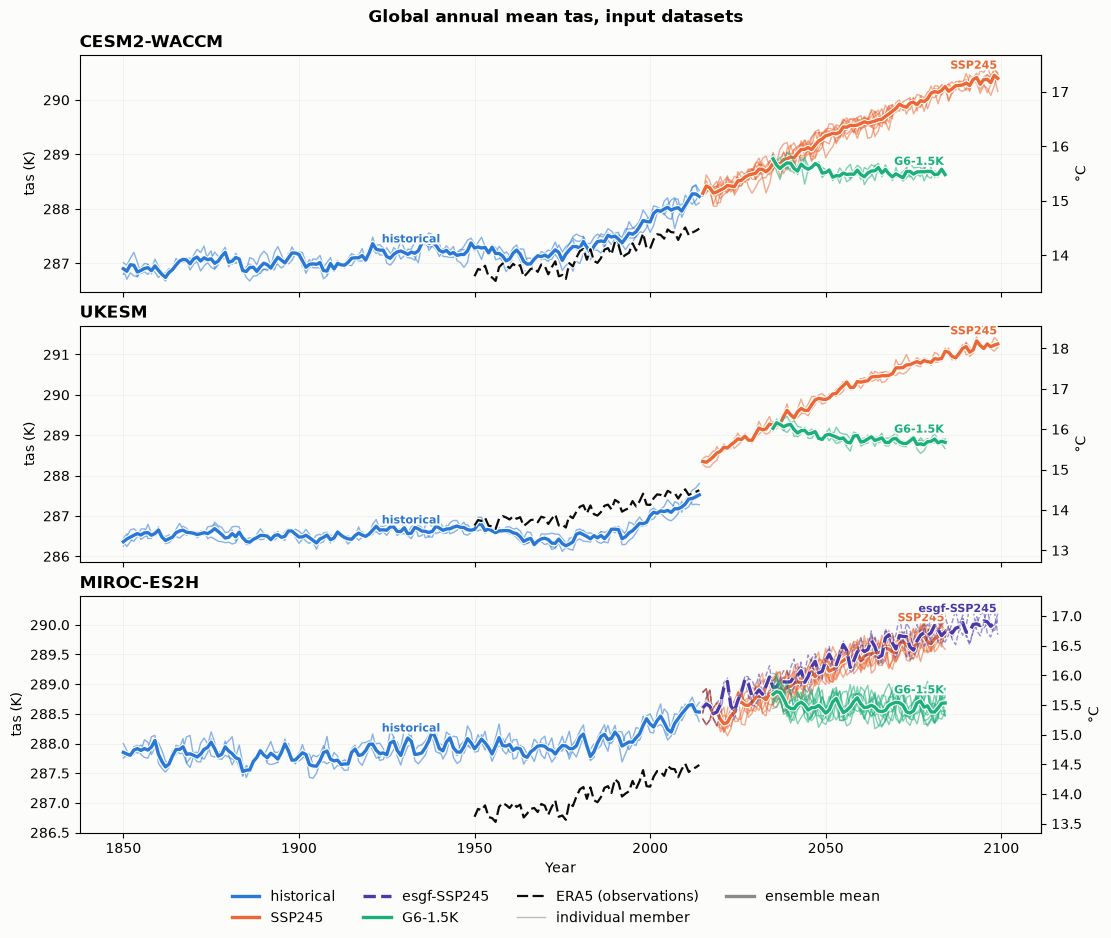

In [10]:
fig, axes = plt.subplots(
    len(GCMS), 1, figsize=(11, 3.1 * len(GCMS)), sharex=True, constrained_layout=True
)
# Pin the surface so the figure keeps a light background under a dark docs theme, which the
# palette was validated against.
fig.patch.set_facecolor(SURFACE)

for ax, gcm in zip(axes, GCMS):
    plot_gcm(ax, annual, gcm, obs=obs_annual)

axes[-1].set_xlabel("Year")
fig.legend(
    handles=legend_handles(annual),
    loc="outside lower center",
    ncol=4,
    frameon=False,
)
fig.suptitle(f"Global annual mean {VARIABLE}, input datasets", fontweight="bold");

### 4.1 The scenario junctions

Zoomed to 1995-2050, where both junctions sit. Only the 2015 handover should be seamless: SAI
deployment begins at 2035, so a change of slope there is the experiment working as intended.

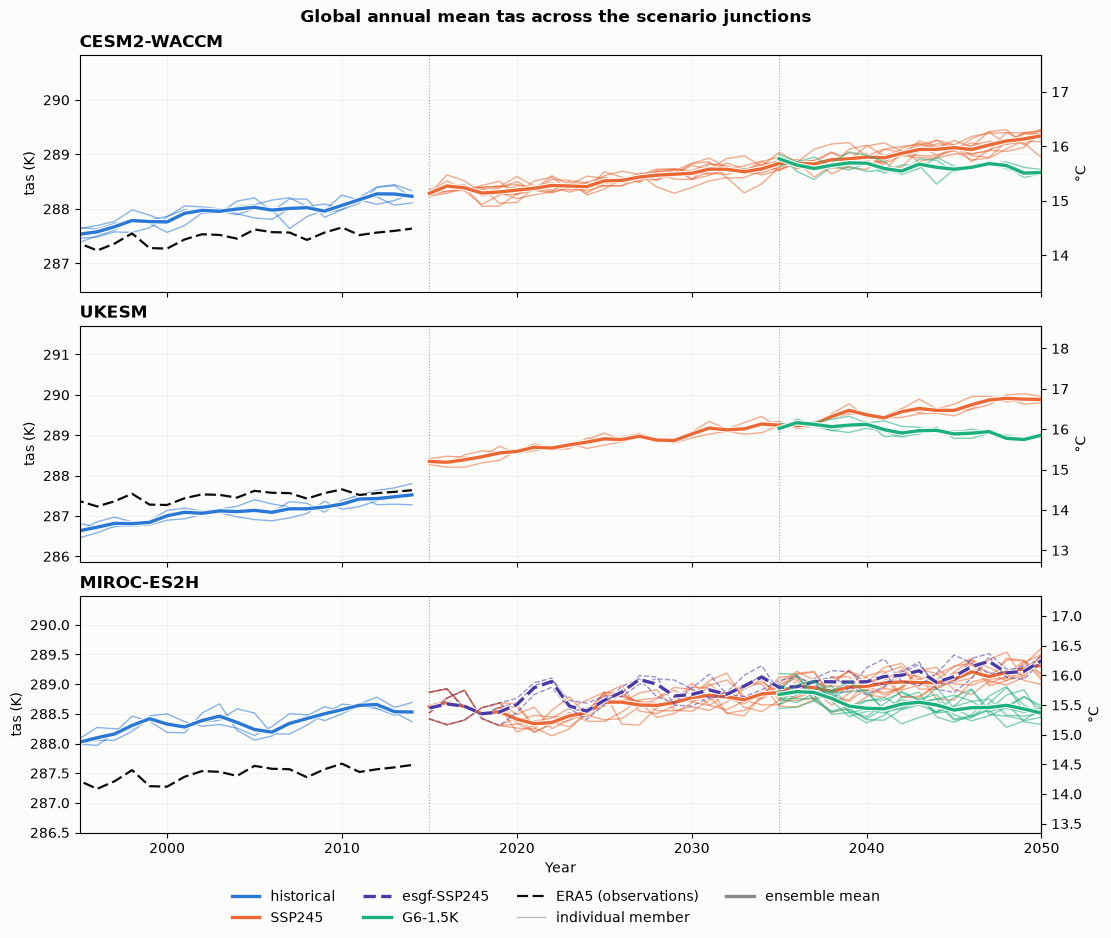

In [11]:
fig, axes = plt.subplots(
    len(GCMS), 1, figsize=(11, 3.1 * len(GCMS)), sharex=True, constrained_layout=True
)
# Pin the surface so the figure keeps a light background under a dark docs theme, which the
# palette was validated against.
fig.patch.set_facecolor(SURFACE)

for ax, gcm in zip(axes, GCMS):
    plot_gcm(ax, annual, gcm, obs=obs_annual, label_means=False)
    for junction in (2015, 2035):
        ax.axvline(junction, color=INK, lw=0.8, ls=":", alpha=0.5, zorder=0)

axes[0].set_xlim(1995, 2050)
axes[-1].set_xlabel("Year")
fig.legend(handles=legend_handles(annual), loc="outside lower center", ncol=4, frameon=False)
fig.suptitle(f"Global annual mean {VARIABLE} across the scenario junctions", fontweight="bold");

## 5. Step-change detection

Ensemble spread is itself a few tenths of a degree, so we measure the jump rather than eyeball it.
For each scenario member, take the last ten years of the run it continues from and its own first
ten, then fit

$$y = a + b\,t + c\,\text{step}$$

with `step` equal to 0 before the junction and 1 after. The trend term $b$ absorbs the forced
warming across the window, which leaves $c$ as the discontinuity alone rather than a mixture of
jump and trend. Dividing $c$ by its standard error says whether it stands out from interannual
scatter, which for global mean temperature is of order 0.1 K.

Parents come from `srm.lineage`, the only authoritative mapping. Resolving one wrong would compare
a member against an unrelated realization and report the ensemble spread as a discontinuity.

| Group | Continues from | Junction | Interpretation |
|---|---|---|---|
| `ssp245` | Its historical parent member | 2015 | Forcing is continuous, so a step is a defect |
| `esgf_ssp245` | Historical member of the same id | 2015 | Same, for MIROC's ESGF-archive SSP245 |
| `g6_1p5k` | Its SSP245 bridge member | 2035 | SAI deployment starts here, so a step is expected |

Only the continuation junctions carry a verdict. The `g6_1p5k` label is deliberately
conservative: SAI onset is a gradual ramp rather than a step, so in practice the trend term
absorbs it and those junctions come out near zero too.

In [12]:
# Which group each scenario continues from. g6_1p5k branches off the SSP245 bridge rather than off
# historical, so its junction is 2035 and its parent is a scenario run, not a historical one.
PARENT_GROUP = {"ssp245": "historical", "esgf_ssp245": "historical", "g6_1p5k": "ssp245"}
CONTINUATION = {"ssp245", "esgf_ssp245"}
WINDOW = 10


def parent_member(gcm: str, group: str, member: str) -> str | None:
    """The member of ``PARENT_GROUP[group]`` that ``member`` is supposed to continue from."""
    # MIROC's esgf_ssp245 members already carry historical-format ids and hold no lineage entry of
    # their own, so they map onto the identically named historical member.
    if group == "esgf_ssp245":
        return member
    historical, ssp245_bridge, _ = resolve_member_lineage(
        gcm, GROUP_TO_SCENARIO[group], member, VARIABLE
    )
    return historical if group == "ssp245" else ssp245_bridge


def step_change(pre: pd.Series, post: pd.Series) -> dict:
    """Least-squares fit of level, trend, and step across a junction.

    Parameters
    ----------
    pre, post : pd.Series
        Annual means indexed by year, from the parent run and the child run respectively.

    Returns
    -------
    dict
        ``step_K`` is the fitted discontinuity, ``se_K`` its standard error, ``t`` their ratio,
        and ``resid_sd`` the residual scatter of the fit, which is the interannual variability the
        step is being judged against.
    """
    years = np.concatenate([pre.index.to_numpy(), post.index.to_numpy()]).astype(float)
    values = np.concatenate([pre.to_numpy(), post.to_numpy()])
    step = np.concatenate([np.zeros(len(pre)), np.ones(len(post))])

    design = np.column_stack([np.ones_like(years), years - years.mean(), step])
    beta, *_ = np.linalg.lstsq(design, values, rcond=None)

    residual = values - design @ beta
    dof = len(values) - design.shape[1]
    variance = float(residual @ residual) / dof
    standard_error = float(np.sqrt(variance * np.linalg.inv(design.T @ design)[2, 2]))

    return {
        "step_K": float(beta[2]),
        "se_K": standard_error,
        "t": float(beta[2] / standard_error) if standard_error > 0 else np.nan,
        "resid_sd": float(np.sqrt(variance)),
        "n_pre": len(pre),
        "n_post": len(post),
    }

In [13]:
def junction_table(df: pd.DataFrame) -> pd.DataFrame:
    """One row per (gcm, scenario, member) junction with its fitted step."""
    kept = df[df.keep & (df.gcm != "ERA5")]
    records = []

    for (gcm, group, member), child in kept.groupby(["gcm", "group", "ensemble_member"], sort=True):
        if group not in PARENT_GROUP:
            continue
        try:
            source = parent_member(gcm, group, member)
        except KeyError:
            # No registered lineage for this combination; srm.lineage is where it would be added.
            records.append({"gcm": gcm, "scenario": group, "member": member, "note": "no lineage"})
            continue
        if source is None:
            continue

        parent_group = PARENT_GROUP[group]
        parent = kept[
            (kept.gcm == gcm) & (kept.group == parent_group) & (kept.ensemble_member == source)
        ]
        if parent.empty:
            records.append(
                {"gcm": gcm, "scenario": group, "member": member, "note": "parent absent"}
            )
            continue

        # The junction is the child's first surviving year, so a leading run of dropped years moves
        # it rather than silently biasing the fit.
        junction = int(child.year.min())
        pre = parent[parent.year < junction].sort_values("year").set_index("year")["mean"]
        post = child.sort_values("year").set_index("year")["mean"]
        pre, post = pre.tail(WINDOW), post.head(WINDOW)
        if len(pre) < 4 or len(post) < 4:
            records.append(
                {"gcm": gcm, "scenario": group, "member": member, "note": "short window"}
            )
            continue

        records.append(
            {
                "gcm": gcm,
                "scenario": GROUP_TO_SCENARIO.get(group, group),
                "member": member,
                "parent": f"{parent_group}/{source}",
                "junction": junction,
                "expected": "step" if group not in CONTINUATION else "continuous",
                **step_change(pre, post),
            }
        )

    table = pd.DataFrame(records)
    flagged = (table.expected == "continuous") & (table.t.abs() > 3)
    table["verdict"] = np.where(
        table.expected != "continuous", "expected step", np.where(flagged, "CHECK", "ok")
    )
    return table.sort_values("t", key=abs, ascending=False, ignore_index=True)


steps = junction_table(annual)
steps.round(3)

,gcm,scenario,member,parent,junction,expected,step_K,se_K,t,resid_sd,n_pre,n_post,verdict
0,UKESM,SSP245,r2i1p1f2,historical/r2i1p1f2,2015,continuous,0.783,0.069,11.398,0.077,10,10,CHECK
1,UKESM,SSP245,r3i1p1f2,historical/r3i1p1f2,2015,continuous,0.616,0.103,5.979,0.115,10,10,CHECK
2,UKESM,SSP245,r12i1p1f2,historical/r12i1p1f2,2015,continuous,0.805,0.137,5.873,0.153,10,10,CHECK
3,MIROC-ES2H,G6-1.5K,r08,ssp245/r08,2035,step,-0.306,0.149,-2.056,0.166,10,10,expected step
4,UKESM,G6-1.5K,r2i1p1f2,ssp245/r2i1p1f2,2035,step,0.228,0.111,2.055,0.123,10,10,expected step
5,MIROC-ES2H,G6-1.5K,r10,ssp245/r10,2035,step,0.274,0.145,1.886,0.162,10,10,expected step
6,UKESM,G6-1.5K,r3i1p1f2,ssp245/r3i1p1f2,2035,step,-0.249,0.149,-1.680,0.165,10,10,expected step
7,MIROC-ES2H,G6-1.5K,r06,ssp245/r06,2035,step,0.304,0.186,1.636,0.207,10,10,expected step
8,MIROC-ES2H,G6-1.5K,r02,ssp245/r02,2035,step,0.264,0.168,1.574,0.187,10,10,expected step
9,CESM2-WACCM,SSP245,006,historical/r1i1p1f1,2015,continuous,0.154,0.100,1.544,0.111,10,10,ok


### 5.1 Continuation junctions

A `CHECK` here means the scenario does not pick up where its historical parent left off, which is
the signature described in
[issue #529](https://github.com/carbonplan/srm-downscaling/issues/529).

In [14]:
continuous = steps[steps.expected == "continuous"]
summary = (
    continuous.groupby(["gcm", "scenario"])
    .agg(
        members=("member", "count"),
        mean_step_K=("step_K", "mean"),
        max_abs_step_K=("step_K", lambda s: s.abs().max()),
        typical_resid_sd_K=("resid_sd", "median"),
        n_flagged=("verdict", lambda s: (s == "CHECK").sum()),
    )
    .round(3)
    .reset_index()
)
summary

,gcm,scenario,members,mean_step_K,max_abs_step_K,typical_resid_sd_K,n_flagged
0,CESM2-WACCM,SSP245,10,0.018,0.154,0.122,0
1,MIROC-ES2H,SSP245,10,-0.059,0.191,0.194,0
2,MIROC-ES2H,esgf-SSP245,3,-0.097,0.223,0.192,0
3,UKESM,SSP245,3,0.735,0.805,0.115,3


### 5.2 The step against the noise

Bars are the fitted step and whiskers the interannual scatter of the same fit. A step comparable to
the scatter is indistinguishable from noise, and one many times larger is a property of the input
data.

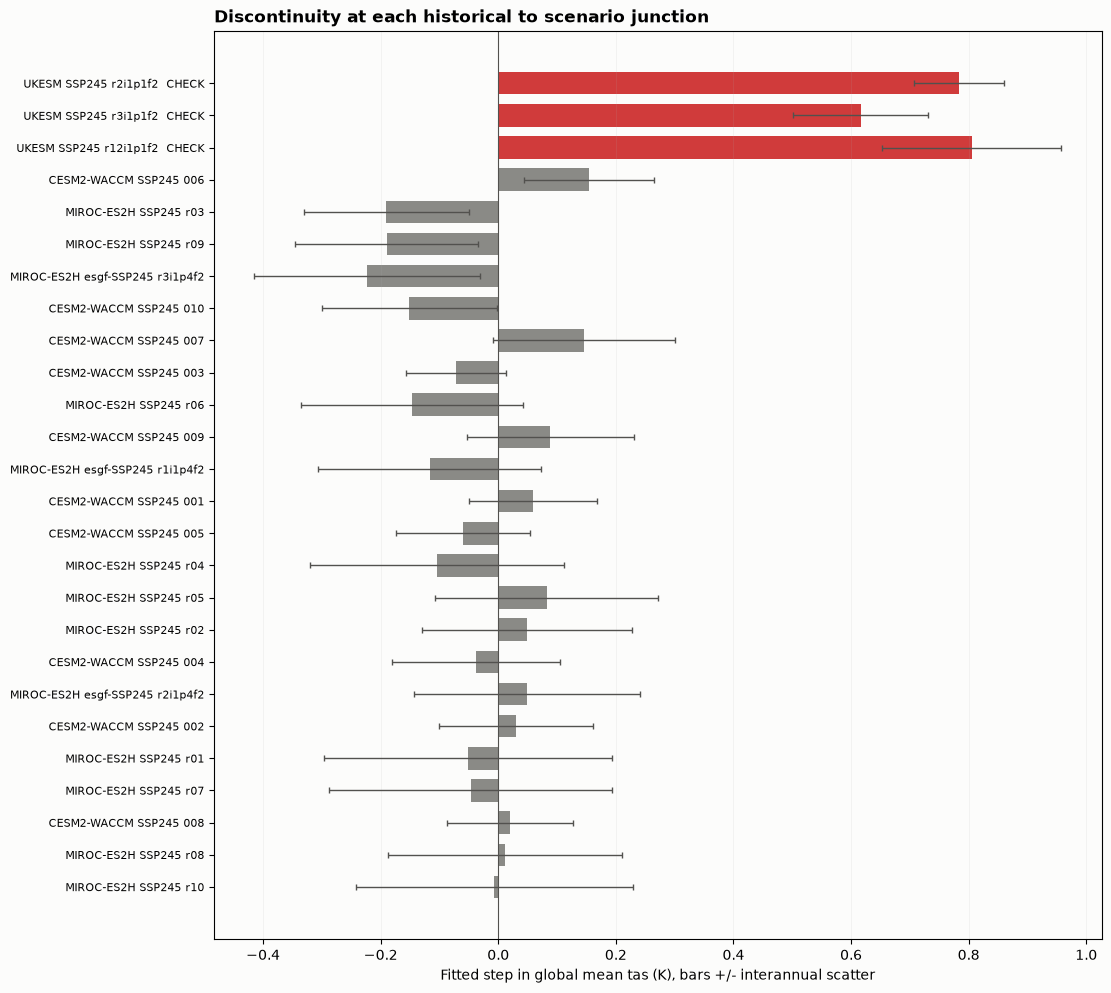

In [15]:
fig, ax = plt.subplots(figsize=(11, 0.32 * len(continuous) + 1.5), constrained_layout=True)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# The verdict is spelled out in the tick label as well as colored, so the flag never rests on
# color alone.
labels = (
    continuous.gcm
    + " "
    + continuous.scenario
    + " "
    + continuous.member
    + np.where(continuous.verdict == "CHECK", "  CHECK", "")
)
positions = np.arange(len(continuous))[::-1]
colors = np.where(continuous.verdict == "CHECK", STATUS_CRITICAL, STATUS_NEUTRAL)

ax.barh(positions, continuous.step_K, color=colors, height=0.7)
ax.errorbar(
    continuous.step_K,
    positions,
    xerr=continuous.resid_sd,
    fmt="none",
    ecolor=INK,
    elinewidth=1,
    capsize=2,
)
ax.set_yticks(positions, labels, fontsize=8)
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel(f"Fitted step in global mean {VARIABLE} (K), bars +/- interannual scatter")
ax.set_title("Discontinuity at each historical to scenario junction", loc="left", fontweight="bold")
ax.grid(axis="x", alpha=0.18, lw=0.5);

## 6. What this run found

Every figure below comes from the cells above, reducing `tas` across all three input stores. This
is a rerun against the regenerated CESM2-WACCM store, after
[PR #532](https://github.com/carbonplan/srm-downscaling/pull/532) trimmed each CESM group to its
canonical time extent and [PR #533](https://github.com/carbonplan/srm-downscaling/pull/533)
restamped the CESM time axis from `time_bnds`.

### The junction check

UKESM is the only model whose scenario runs fail to continue from their historical parent, which
confirms [issue #529](https://github.com/carbonplan/srm-downscaling/issues/529) and puts a number
on it:

| GCM | Scenario | Members | Mean step | Max abs step | Typical interannual sigma | Flagged |
|---|---|---|---|---|---|---|
| UKESM | SSP245 | 3 | +0.735 K | 0.805 K | 0.115 K | 3 of 3 |
| CESM2-WACCM | SSP245 | 10 | +0.018 K | 0.154 K | 0.122 K | 0 |
| MIROC-ES2H | SSP245 | 10 | -0.059 K | 0.191 K | 0.194 K | 0 |
| MIROC-ES2H | esgf-SSP245 | 3 | -0.097 K | 0.223 K | 0.192 K | 0 |

All three UKESM members step the same way and by a similar amount, which is the signature of a
shared cause rather than internal variability; internal variability scatters the sign, as every
other junction in the table does. The smallest UKESM step is still 2.8 times the largest
continuation step anywhere else in the catalog. The fitted 0.74 K is smaller than the roughly 1 K
reported in #529, because the regression's trend term removes the warming that accrues across the
comparison window.

The ERA5 reference identifies which side is the outlier. UKESM `historical` tracks slightly below
ERA5 through 2014, while UKESM `ssp245` opens about 0.7 K above the final observed year, which is
on the order of thirty years of real-world global-mean warming appearing between one December and
the next January. That points the investigation at the SSP245 and G6 runs rather than at the
historical one.

Two consequences follow for the pipeline. `stitch_historical_scenario` concatenates the two runs
and `detrend` estimates the trend with a nine-year centered rolling mean, so from about 2020 the
offset is absorbed into the trend, survives quantile mapping, and is restored by `retrend`; nearer
the junction that window straddles the step and distorts roughly 2011 to 2019, including the last
few historical years. UKESM `G6-1.5K` bridges through `ssp245` per `srm.lineage`, so both UKESM
scenario products inherit this, not SSP245 alone.

### What passed

- CESM2-WACCM and MIROC-ES2H hand off cleanly at 2015. The largest continuation step among them is
  0.223 K, on MIROC's esgf-SSP245, against that same group's 0.192 K of interannual scatter.
- No model steps at the 2035 SAI branch. Every `g6_1p5k` junction lands within 0.31 K with mixed
  signs and |t| at most 2.1, so the "expected step" label above is conservative: SAI onset is a
  gradual ramp that the trend term absorbs rather than a step. The G6 bridge splice therefore
  introduces no detectable global-mean artifact in any model.
- MIROC's larger interannual scatter (0.19 K against 0.12 K) is a model property rather than a
  defect, and it leaves MIROC roughly 60% less sensitive to a small step than the other two.

### The CESM time-axis fixes

Rerunning against the regenerated store is a check on #532 and #533, and it passes. The
CESM2-WACCM rows of the section 2 inventory now end where the scenario definitions say they should:

| Group | Before | After |
|---|---|---|
| `historical` | 1850-01-01 to 2015-01-16, 60281 days | 1850-01-01 to 2014-12-31, 60265 days |
| `g6_1p5k` | 2035-01-01 to 2085-01-01, 18264 days | 2035-01-01 to 2084-12-31, 18263 days |

Two things follow. The seven partial member-years those extents used to produce, 2015 for each of
the four `historical` members and 2085 for each of the three `g6_1p5k` members, are now absent from
the store rather than dropped by a guard, which is why this run reduces 4575 member-years where the
previous one reduced 4582. Restamping each daily mean to the start of its averaging interval also
moves a day of values across each year boundary, so every CESM annual mean shifts a little:
comparing the two runs, the fitted steps of section 5 are identical to three decimals and no t
statistic moves by more than 0.005, so no verdict changes.

### Coverage

278 of 4575 member-years were dropped, all of them on `coverage` and none on `n_days`, and every
one sits at a record edge:

| Drop | Years | Cause |
|---|---|---|
| CESM `historical` / `001` | 1850-1977 | ESGF member 001 begins in 1978 |
| CESM `ssp245` / 006-010 | 2070-2099 | All-NaN tail; these members end in 2069 |

No store carries an unexplained mid-record gap. `coverage` is the guard carrying this run on its
own, because a `NaN` cell drops out of numerator and denominator alike and leaves the surviving
cells averaging to something plausible; without it all 278 of these years would have entered the
figures as ordinary-looking numbers. Note that the CESM `ssp245` store pads to 2099 with NaN
rather than ending its axis at 2069, so any consumer that skips a coverage check will average NaN
there.

### MIROC SSP245 changes source at 2020

The junction zoom shows the ten MIROC `ssp245` members collapsing onto three tracks between 2015
and 2019, coincident with the three `esgf_ssp245` members, then fanning out into a genuine
ten-member spread from 2020. That matches the note in `srm.lineage` that the GeoMIP baseline starts
in 2020 and ESGF SSP245 fills the years before it, and it places that fill inside the input store
rather than in the pipeline. Three things follow:

- The MIROC `ssp245` ensemble carries three distinct realizations before 2020, not ten, so its
  spread over those years is not a measure of internal variability.
- The group contains a source change at 2020, after which the two sources diverge by roughly 0.2 to
  0.3 K until about 2035.
- The MIROC SSP245 row of the junction table compares a historical window against a post-junction
  window that straddles that source change. Its step is small either way, but the window is not
  homogeneous.

The cheap confirmation is the across-member standard deviation per year from the cached table: near
zero before 2020 and around 0.2 K after it would settle the question without re-reading the stores.

### Follow-ups for a flagged junction

1. Rerun with `WINDOW` set to 5 and to 20. A configuration mismatch is insensitive to the choice,
   and an artifact of one anomalous year is not.
2. Check whether the step is global or regional. A whole-run offset points at model configuration,
   and a regional one at a specific field.
3. Read `docs/srm-provenance.csv`, which records the parent experiment and variant labels per run.
   A mismatch there is the likeliest explanation for a configuration change between a run and its
   scenario.
4. Delete the cached CSV at `CACHE_PATH` before a rerun meant to pick up regenerated data, since it
   is keyed by variable alone and not by store version. This rerun needed exactly that.

Setting `VARIABLE` to `pr` or `rsds` reruns everything unchanged, but the interpretation does not
transfer: precipitation is strongly skewed with much larger interannual variability, so the same t
statistic does not carry the same weight.


In [16]:
cluster.shutdown()